# Intelligents OQS

## Imports

In [1]:
import numpy as np
from scipy.linalg import expm as expMatrix
from sympy.physics.quantum.dagger import Dagger
import math

from sklearn.impute import SimpleImputer
from sklearn.model_selection import StratifiedKFold,train_test_split, KFold
from sklearn.multiclass import OneVsRestClassifier
from sklearn.utils.multiclass import unique_labels
from sklearn.utils.validation import check_array, check_is_fitted, check_X_y
from sklearn.preprocessing import MinMaxScaler
from sklearn.base import BaseEstimator, ClassifierMixin
from sklearn import preprocessing
from sklearn.metrics import f1_score, recall_score, precision_score, accuracy_score, make_scorer, roc_auc_score, classification_report

from imblearn.over_sampling import SMOTE
from ucimlrepo import fetch_ucirepo

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import pdflatex

import pandas as pd

from all_iqc import *


## Base de Dados

In [3]:
#Gerando o dataset
iris = fetch_ucirepo(id=53)
# data (as pandas dataframes) 
X_iris = iris.data.features 
X_iris = X_iris.values
y_iris = iris.data.targets
y_iris = y_iris.values

#Parâmetros
RANDOM_SEED = 1
LEARNING_RATE = 0.01
N_FEATURES = len(X_iris[0])
N_SAMPLES = len(X_iris)
N_PRINTINGS = N_SAMPLES//2
N_QUBITS=math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
weights=np.full(N_FEATURES,0.1)
QUBITS=[i for i in range(N_QUBITS)]
N_SHOTS=2048
N_ITER=200

## Tratamento do Dataset

In [4]:
def normalize_iqc_ail(data, normalize_col=False, normalize_lin=False):
    if normalize_col:
        data = preprocessing.normalize(data,axis=0,norm='l2')
        '''
        Perceba que normalizando apenas a coluna, podemos ter amplitudes dos estados em que a norma do estado não fosse igual a 1. Para resolvermos isso, devemos
        normalizar as linhas entre si

        '''
        data = preprocessing.normalize(data,axis=1,norm='l2')
    if normalize_lin:
        data = preprocessing.normalize(data,axis=1,norm='l2') #Normaliza a linha entre [-1,1]
    return data
    
X_iris_iqc_ail_coluna=normalize_iqc_ail(X_iris, normalize_col=True, normalize_lin=False)
X_iris_iqc_ail_linha=normalize_iqc_ail(X_iris,normalize_col=False,normalize_lin=True)

#### Boxplot IQC:AIL Column Normalized

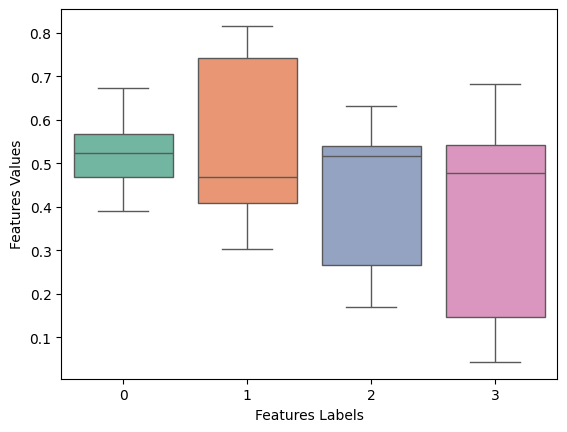

In [5]:
fig, ax = plt.subplots()
sns.boxplot(X_iris_iqc_ail_coluna, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_coluna.svg')

#### Boxplot IQC:AIL Line Normalized

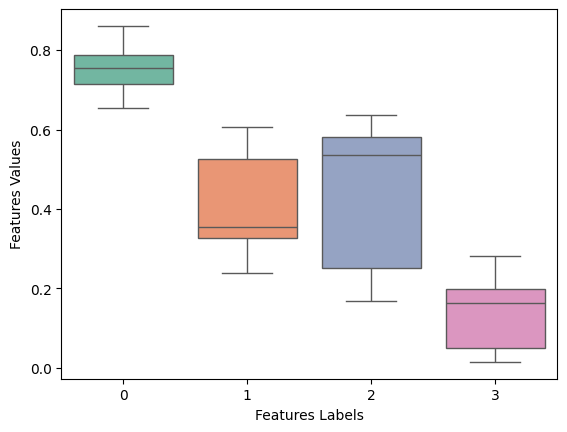

In [6]:
fig, ax = plt.subplots()
sns.boxplot(X_iris_iqc_ail_linha, palette="Set2",ax=ax)
ax.set_xlabel('Features Labels')
ax.set_ylabel('Features Values')
plt.savefig('boxplot_iris_iqc_ail_linha.svg')

## Treinamento

#### IQC AIL LINHA

In [6]:
'''
for SEED in range(n_times_kfold):
    scores, f1scores, output_dict = execute_training_test_k_fold(
                    X, 
                    y, 
                    k_folds=k_times_fold,
                    random_seed = SEED, 
                    classifier_function=classifier_function, 
                    dic_classifier_params=dic_classifier_params,
                    one_vs_classifier=OneVsRestClassifier, 
                    dic_training_params=dic_training_params,
                    print_each_fold_metric=True,
                    print_avg_metric=True)
    scores_list.append(scores)
    f1scores_list.append(f1scores)
    negativities_list.append(output_dict["negativities"])
'''

k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 1



dic_training_params = {"max_iter": 200,
    "accuracy_succ": 0.99,
    "plot_graphs_and_metrics": False,
    "plot_graphs_in_classifier": False,
    "random_seed": 1,
    "learning_rate": 0.01,
    "refit_db":True,
    "reset_weights_epoch":0,
    "do_classes_refit":True,
    "batch":False}
    
scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.9s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.3609151108778655), np.float64(0.2851480891416177), np.float64(0.362460427553611)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.60      0.75         5
Iris-versicolor       0.62      1.00      0.77         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.80        15
      macro avg       0.88      0.80      0.80        15
   weighted avg       0.88      0.80      0.80        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   46.0s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.3610712900798505), np.float64(0.2949760143286903), np.float64(0.36171534249053755)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.71      1.00      0.83         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.87        15
      macro avg       0.90      0.87      0.87        15
   weighted avg       0.90      0.87      0.87        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   47.0s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3588252715063705), np.float64(0.29229822203407413), np.float64(0.3620264420338887)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   41.0s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.35838103099350754), np.float64(0.2965273082791945), np.float64(0.36451798656814344)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.3s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.35691634337922123), np.float64(0.2930882903694323), np.float64(0.36313200285660124)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.57      0.80      0.67         5
 Iris-virginica       0.75      0.60      0.67         5

       accuracy                           0.73        15
      macro avg       0.77      0.73      0.74        15
   weighted avg       0.77      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.8799999999999999 F1-Scores = 0.8806241906241906 Negativity = [np.float64(0.33617454252436474), np.float64(0.3392542156330261), np.float64(0.34031901827354655)]
Media Score dos N K-Fold 0.8799999999999999
Maior Score dos K-Fold 0.8799999999999999
Min Score dos K-Fold 0.8799999999999999
Media Score dos K-Fold [np.float64(0

#### IQC AIL COLUNA

In [7]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = True
dic_classifier_params["normalize_axis"] = 0


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   25.3s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.3160829026169549), np.float64(0.1890194056208703), np.float64(0.19127214285082653)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.6s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.30612858429699963), np.float64(0.19148539277470744), np.float64(0.1868425884528807)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.8s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3041774658173706), np.float64(0.19181783028963784), np.float64(0.19363134419227374)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   39.8s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.2938597845386922), np.float64(0.19251057152638343), np.float64(0.1895272391321558)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.9s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.2942623343792416), np.float64(0.19914486948117613), np.float64(0.20126402738318577)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.9533333333333334 F1-Scores = 0.9528619528619527 Negativity = [np.float64(0.23212481702955057), np.float64(0.22815218850819594), np.float64(0.22312796966180637)]
Media Score dos N K-Fold 0.9533333333333334
Maior Score dos K-Fold 0.9533333333333334
Min Score dos K-Fold 0.9533333333333334
Media Score dos K-Fold [np.float64(

#### IQC LINHA

In [8]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   27.4s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.35975520630353003), np.float64(0.291944357336139), np.float64(0.3622455142533342)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.60      0.75         5
Iris-versicolor       0.56      1.00      0.71         5
 Iris-virginica       1.00      0.60      0.75         5

       accuracy                           0.73        15
      macro avg       0.85      0.73      0.74        15
   weighted avg       0.85      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.0s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.3472761213059779), np.float64(0.286050280650224), np.float64(0.36147436302349534)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   47.4s finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3588252715063705), np.float64(0.29229822203407413), np.float64(0.3620264420338887)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      0.80      0.89         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   42.7s finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.35838103099350754), np.float64(0.2965273082791945), np.float64(0.36451798656814344)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   40.1s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.35691634337922123), np.float64(0.2930882903694323), np.float64(0.36313200285660124)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.57      0.80      0.67         5
 Iris-virginica       0.75      0.60      0.67         5

       accuracy                           0.73        15
      macro avg       0.77      0.73      0.74        15
   weighted avg       0.77      0.73      0.74        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.86 F1-Scores = 0.8602068302068302 Negativity = [np.float64(0.3379816926310011), np.float64(0.3316002549932324), np.float64(0.3407124411188132)]
Media Score dos N K-Fold 0.86
Maior Score dos K-Fold 0.86
Min Score dos K-Fold 0.86
Media Score dos K-Fold [np.float64(0.86)]


#### IQC COLUNA

In [9]:
k_times_fold = 10
classifier_function = iqc_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0


dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.8s finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.3160829026169549), np.float64(0.1890194056208703), np.float64(0.19127214285082653)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      0.80      0.89         5
Iris-versicolor       0.83      1.00      0.91         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   38.2s finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.30612858429699963), np.float64(0.19148539277470744), np.float64(0.1868425884528807)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   32.3s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.3041774658173706), np.float64(0.19181783028963784), np.float64(0.19363134419227374)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   35.8s finished
[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


K-Fold #8
Mean negativities for all classes: [np.float64(0.2938597845386922), np.float64(0.19251057152638343), np.float64(0.1895272391321558)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      1.00      1.00         5
 Iris-virginica       1.00      1.00      1.00         5

       accuracy                           1.00        15
      macro avg       1.00      1.00      1.00        15
   weighted avg       1.00      1.00      1.00        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:   13.3s finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.2942623343792416), np.float64(0.19914486948117613), np.float64(0.20126402738318577)]
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         5
Iris-versicolor       1.00      0.80      0.89         5
 Iris-virginica       0.83      1.00      0.91         5

       accuracy                           0.93        15
      macro avg       0.94      0.93      0.93        15
   weighted avg       0.94      0.93      0.93        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.9533333333333334 F1-Scores = 0.9528619528619527 Negativity = [np.float64(0.23212481702955057), np.float64(0.22815218850819594), np.float64(0.22312796966180637)]
Media Score dos N K-Fold 0.9533333333333334
Maior Score dos K-Fold 0.9533333333333334
Min Score dos K-Fold 0.9533333333333334
Media Score dos K-Fold [np.float64(

#### IQC_PQ, NF2

In [ ]:
k_times_fold = 10
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 1
N_qubits_tgt = 2
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.


#### IQC_PQ, NF4

In [8]:
k_times_fold = 10
classifier_function = iqcpq_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
N_qubits_tgt = 4
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+N_qubits_tgt) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = N_qubits_tgt

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.5min finished


K-Fold #0
Mean negativities for all classes: [np.float64(0.7021452279809623), np.float64(0.5770969565292686), np.float64(0.5946733294601361)]
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.5min finished


K-Fold #1
Mean negativities for all classes: [np.float64(0.6900245265166057), np.float64(0.5958587592139757), np.float64(0.6147224545535204)]
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.6min finished


...

K-Fold #7
Mean negativities for all classes: [np.float64(0.7015838000362814), np.float64(0.5929173049559852), np.float64(0.6174691021575709)]
                 precision    recall  f1-score   support

    Iris-setosa       0.33      1.00      0.50         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.11      0.33      0.17        15
   weighted avg       0.11      0.33      0.17        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  1.9min finished


K-Fold #8
Mean negativities for all classes: [np.float64(0.7107801515048144), np.float64(0.5708518767001464), np.float64(0.5841133380340836)]
                 precision    recall  f1-score   support

    Iris-setosa       0.36      1.00      0.53         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.12      0.33      0.18        15
   weighted avg       0.12      0.33      0.18        15

-------------------------------------------------------------------------------------------------------------------


[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of   3 | elapsed:  4.1min finished


K-Fold #9
Mean negativities for all classes: [np.float64(0.6904388232289386), np.float64(0.6036571824027663), np.float64(0.6176529535331181)]
                 precision    recall  f1-score   support

    Iris-setosa       0.36      1.00      0.53         5
Iris-versicolor       0.00      0.00      0.00         5
 Iris-virginica       0.00      0.00      0.00         5

       accuracy                           0.33        15
      macro avg       0.12      0.33      0.18        15
   weighted avg       0.12      0.33      0.18        15

-------------------------------------------------------------------------------------------------------------------
AVG: Scores = 0.33333333333333337 F1-Scores = 0.17017543859649123 Negativity = [np.float64(0.624638504656789), np.float64(0.6335352467613673), np.float64(0.6112285991501899)]
Media Score dos N K-Fold 0.33333333333333337
Maior Score dos K-Fold 0.33333333333333337
Min Score dos K-Fold 0.33333333333333337
Media Score dos K-Fold [np.float64(0

#### IQCnDSE

In [ ]:
k_times_fold = 10
classifier_function = iqcndsE_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

#### IQC_ANGLE

In [ ]:
k_times_fold = 10
classifier_function = iqc_angle_classifier
dic_classifier_params = {}
dic_classifier_params["sigma_q_params"] = [1,1,1,0]
dic_classifier_params["use_polar_coordinates_on_sigma_q"] = False
dic_classifier_params["load_inputvector_env_state"] = False
dic_classifier_params["normalize_axis"] = 0
dic_classifier_params["N_qubits"] = math.ceil(np.log2(N_FEATURES)+1) #Nqubits do circuito
dic_classifier_params["N_qubits_tgt"] = 1

dic_training_params = {"max_iter": 200,
"accuracy_succ": 0.99,
"plot_graphs_and_metrics": False,
"plot_graphs_in_classifier": False,
"random_seed": 1,
"learning_rate": 0.01,
"refit_db":True,
"reset_weights_epoch":0,
"do_classes_refit":True,
"batch":False}

scores_list = []
f1scores_list = []
negativities_list = []
scores, f1scores, output_dict = execute_training_test_k_fold(
                X_iris, 
                y_iris, 
                k_folds=k_times_fold,
                random_seed = 1, 
                classifier_function=classifier_function, 
                dic_classifier_params=dic_classifier_params,
                one_vs_classifier=OneVsRestClassifier, 
                dic_training_params=dic_training_params,
                print_each_fold_metric=True,
                print_avg_metric=True)
scores_list.append(scores)
f1scores_list.append(f1scores)
negativities_list.append(output_dict["negativities"])
print("Media Score dos N K-Fold", np.mean([np.mean(i) for i in scores_list]))
print("Maior Score dos K-Fold", max([np.mean(i) for i in scores_list]))
print("Min Score dos K-Fold", min([np.mean(i) for i in scores_list]))

print("Media Score dos K-Fold", [np.mean(i) for i in scores_list])

NameError: name 'iqcangle_classifier' is not defined